In [210]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import precision_score, recall_score, f1_score



In [263]:
df=pd.read_csv(r'C:\datascience\datascience\datasets\bank.csv')
dfz2=df
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


Age	-Age of customer,
Job	-Job of customer
Martial	-Martial status of customer
Education	-Customer education level
Default-	Has credit in default?
Housing-	If costumer has housing loan
Loan-	Has Personal Loan
Balance	-Customer's individual balance
Contact-	Communication type
Month-	Last contact month of year
Day	-Last contact day of the week
Duration-	Last contact duration, in seconds
Campaign	-Number of contacts performed during this campaign and for this client
Pdays	-Number of days that passed by after the client was last contacted from a previous campaign
Previous	-Number of contacts performed before this campaign and for this client
Poutcome	-outcome of the previous marketing campaign
Deposit	-has the client subscribed a term deposit

In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [213]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [214]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [215]:
df.dtypes


age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

In [216]:
#no empty values , mix of int and object datatype

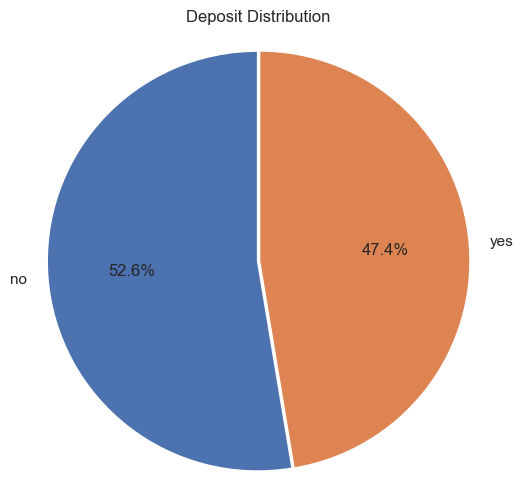

In [217]:
import matplotlib.pyplot as plt

# Value counts
counts = df['deposit'].value_counts()
labels = counts.index
sizes = counts.values

# Create explode list: pull out only "yes" slightly
explode = [0.01 if label == 'yes' else 0 for label in labels]

# Plot
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', explode=explode, startangle=90)
plt.title("Deposit Distribution")
plt.axis('equal')
plt.show()



C:\Users\rohit\AppData\Local\Temp\ipykernel_19108\1609903358.py:5: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\rohit\AppData\Local\Temp\ipykernel_19108\1609903358.py:5: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\rohit\AppData\Local\Temp\ipykernel_19108\1609903358.py:5: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\rohit\AppData\Local\Temp\ipykernel_19108\1609903358.py:5: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\rohit\AppData\Local\Temp\ipykernel_19108\1609903358.py:5: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\rohit\

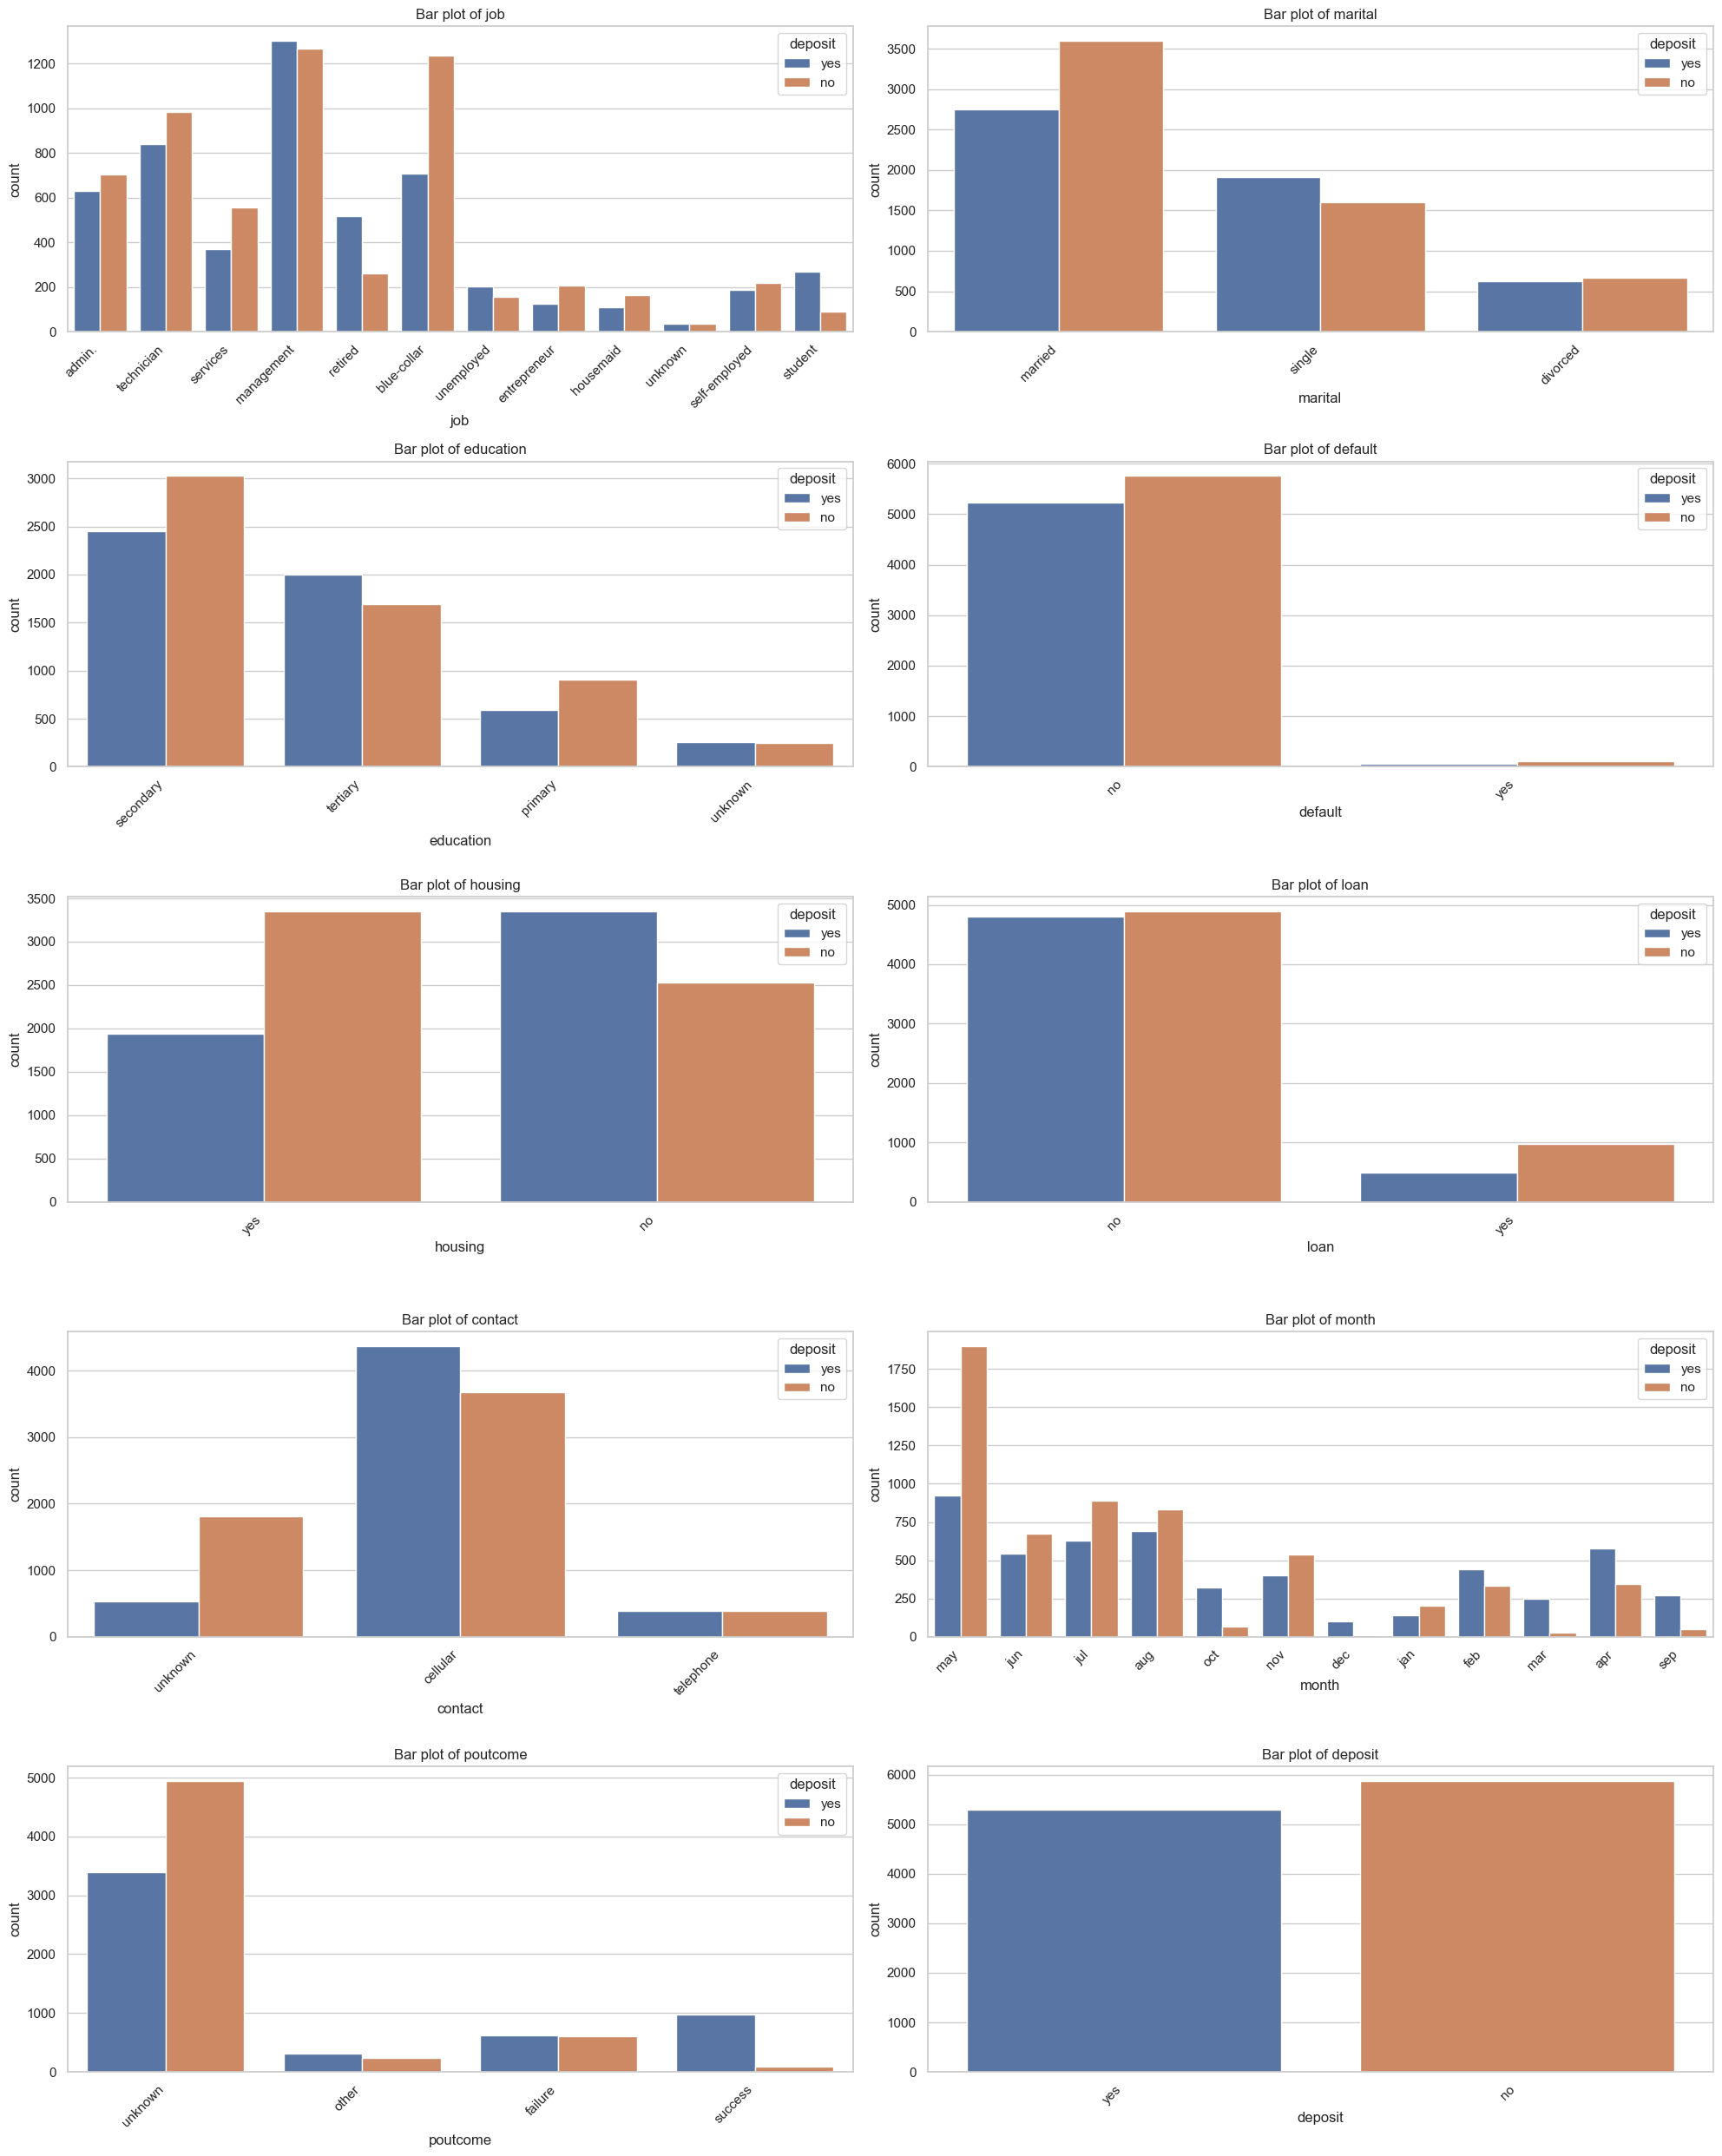

In [218]:
#bar plot of all object column
fig, ax = plt.subplots(nrows=int(len(df.select_dtypes(include=['object']).columns)/2), ncols=2, figsize=(20, 25))
for i, col in enumerate(df.select_dtypes(include=['object']).columns):
    sns.countplot(x=col, data=df, hue='deposit', ax=ax[i//2, i%2])
    ax[i//2, i%2].set_xticklabels(ax[i//2, i%2].get_xticklabels(), rotation=45, ha='right')
   
    ax[i//2, i%2].set_title('Bar plot of {}'.format(col))
    plt.tight_layout()

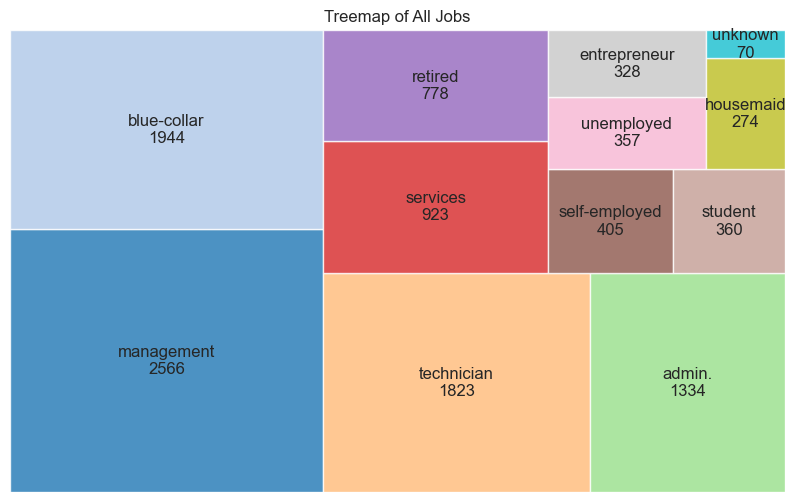

In [219]:
#Treemap of all jobs\
import matplotlib.pyplot as plt
import squarify

# Count jobs
job_counts = df['job'].value_counts()
labels = [f'{job}\n{count}' for job, count in zip(job_counts.index, job_counts.values)]
sizes = job_counts.values
colors = [plt.cm.tab20(i / float(len(labels))) for i in range(len(labels))]

# Plot
plt.figure(figsize=(10, 6))
squarify.plot(sizes=sizes, label=labels, alpha=0.8, color=colors, text_kwargs={'fontsize':12})
plt.title("Treemap of All Jobs")
plt.axis('off')
plt.show()






In [220]:
import plotly.express as px

fig = px.box(df, x="job", y="age", color="job", color_discrete_map={
    "admin.": "red",
    "blue-collar": "blue",
    "entrepreneur": "green",
    "housemaid": "yellow",
    "management": "purple",
    "retired": "orange",
    "self-employed": "pink",
    "services": "brown",
    "student": "grey",
    "technician": "turquoise",
    "unemployed": "black",
    "unknown": "white"
}, points="all")

fig.update_layout(
    title='Distribution of Age by Occupation',
    xaxis=dict(
        title='Occupation'
    ),
    yaxis=dict(
        title='Age'
    )
)

fig.show()


In [221]:
mean_balance = df.groupby('job')['balance'].mean().reset_index()

# Barpolar chart
fig = px.bar_polar(
    mean_balance,
    r='balance',
    theta='job',
    color='job',
    title='Mean Balance by Job',)

fig.show()

In [222]:
import pandas as pd
import plotly.express as px

# Assuming df is already defined and contains 'balance' and 'marital' columns

fig = px.histogram(
    df,
    x="balance",
    color="marital",  # hue in seaborn
    barmode="overlay",  # or 'group' if you want side-by-side bars
    title="Balance Distribution by Marital Status",
    color_discrete_sequence=px.colors.sequential.Viridis
)

fig.update_layout(
    xaxis_title="Balance",
    yaxis_title="Count",
    hovermode="x unified"
)

fig.show()



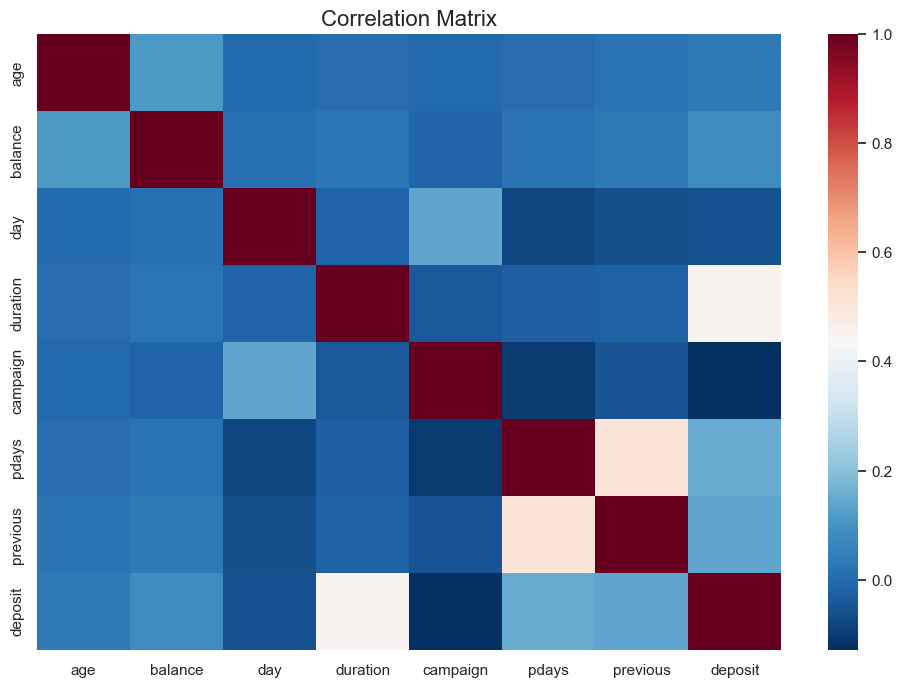

In [223]:


from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
fig = plt.figure(figsize=(12,8))
df['deposit'] = LabelEncoder().fit_transform(df['deposit'])



# Separate both dataframes into 
numeric_df = df.select_dtypes(exclude="object")
# categorical_df = df.select_dtypes(include="object")

corr_numeric = numeric_df.corr()


sns.heatmap(corr_numeric, cbar=True, cmap="RdBu_r")
plt.title("Correlation Matrix", fontsize=16)
plt.show()

C:\Users\rohit\AppData\Local\Temp\ipykernel_19108\1879032717.py:9: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'below_average' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.



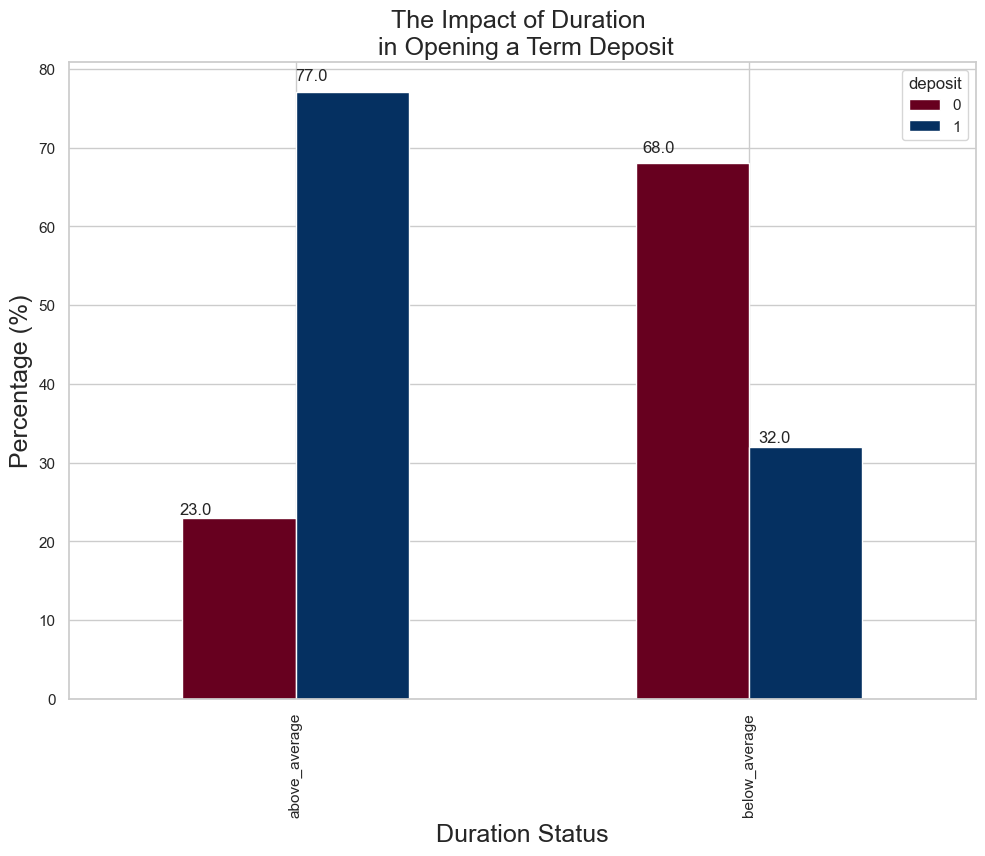

In [224]:
sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.set_style('whitegrid')
avg_duration = df['duration'].mean()

lst = [df]
df["duration_status"] = np.nan

for col in lst:
    col.loc[col["duration"] < avg_duration, "duration_status"] = "below_average"
    col.loc[col["duration"] > avg_duration, "duration_status"] = "above_average"
    
pct_term = pd.crosstab(df['duration_status'], df['deposit']).apply(lambda r: round(r/r.sum(), 2) * 100, axis=1)


ax = pct_term.plot(kind='bar', stacked=False, cmap='RdBu')
plt.title("The Impact of Duration \n in Opening a Term Deposit", fontsize=18)
plt.xlabel("Duration Status", fontsize=18);
plt.ylabel("Percentage (%)", fontsize=18)

for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.02, p.get_height() * 1.02))
    

plt.show()

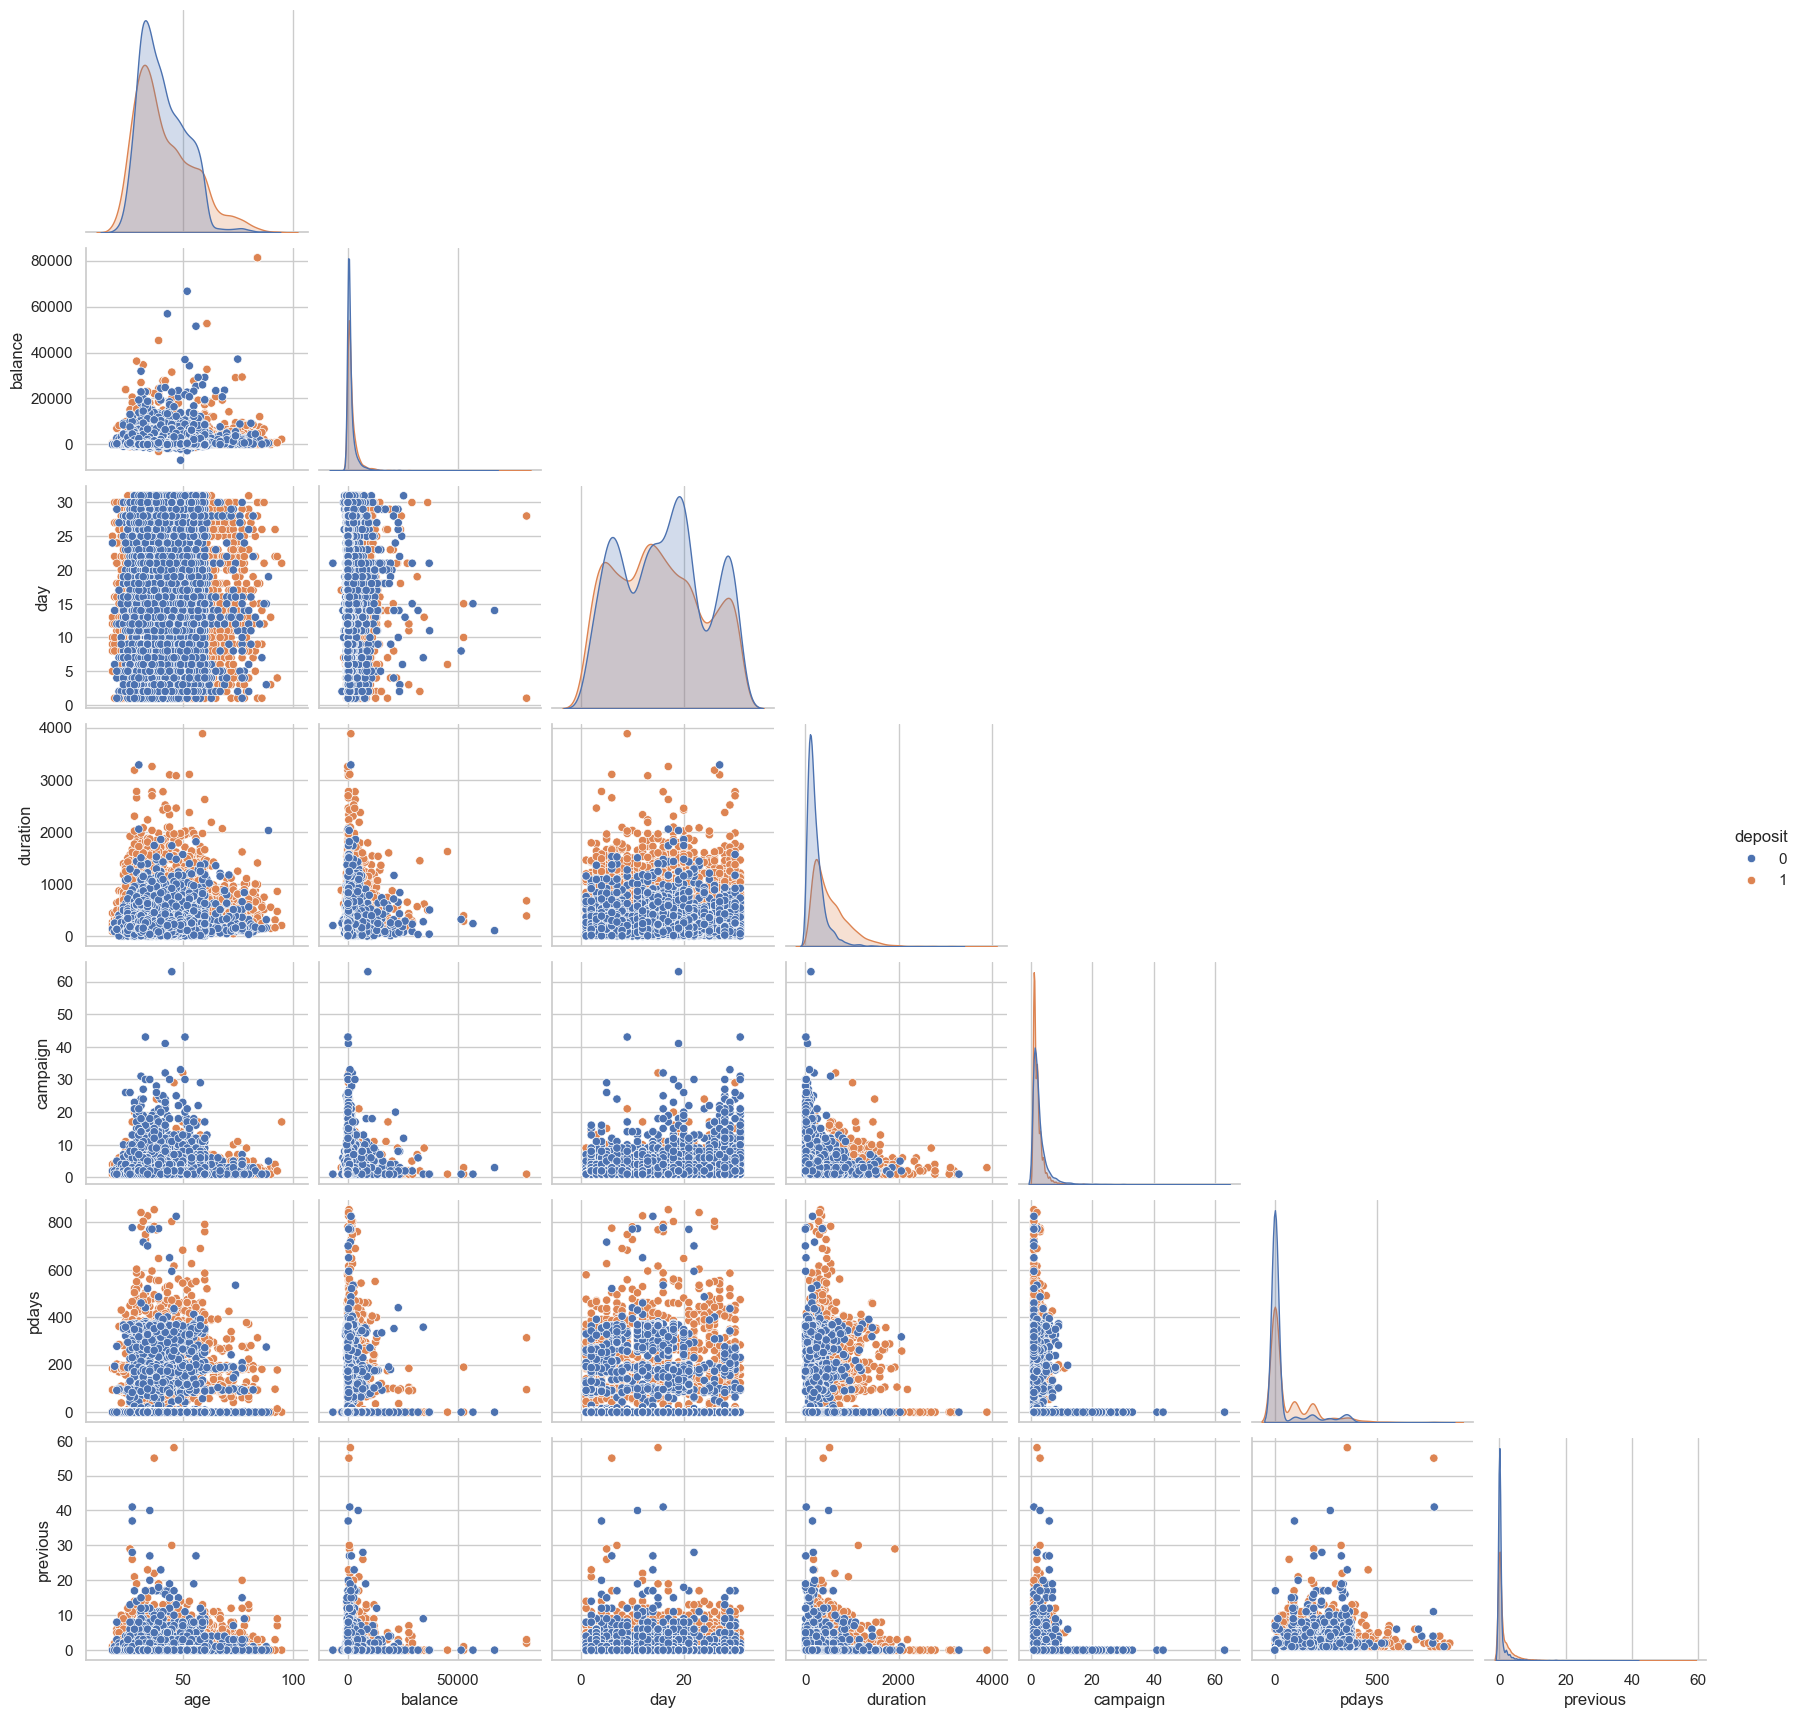

In [225]:
sns.pairplot(df,hue='deposit',corner=True)

In [226]:
from sklearn.preprocessing import LabelEncoder
import pickle

encoders = {}

# Columns to encode
cols_to_encode = ['marital', 'housing', 'loan', 'default']

# Apply label encoding and store each encoder
for col in cols_to_encode:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le  
# Save all encoders to a file
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)



df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,duration_status
0,59,admin.,1,secondary,0,2343,1,0,unknown,5,may,1042,1,-1,0,unknown,1,above_average
1,56,admin.,1,secondary,0,45,0,0,unknown,5,may,1467,1,-1,0,unknown,1,above_average
2,41,technician,1,secondary,0,1270,1,0,unknown,5,may,1389,1,-1,0,unknown,1,above_average
3,55,services,1,secondary,0,2476,1,0,unknown,5,may,579,1,-1,0,unknown,1,above_average
4,54,admin.,1,tertiary,0,184,0,0,unknown,5,may,673,2,-1,0,unknown,1,above_average
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,2,primary,0,1,1,0,cellular,20,apr,257,1,-1,0,unknown,0,below_average
11158,39,services,1,secondary,0,733,0,0,unknown,16,jun,83,4,-1,0,unknown,0,below_average
11159,32,technician,2,secondary,0,29,0,0,cellular,19,aug,156,2,-1,0,unknown,0,below_average
11160,43,technician,1,secondary,0,0,0,1,cellular,8,may,9,2,172,5,failure,0,below_average


In [227]:

df_encoded = pd.get_dummies(df, columns=['job', 'education', 'month', 'contact', 'poutcome', 'duration_status'])
df_encoded = df_encoded.astype(int)

# Save the column structure
import pickle

with open('onehot_columns.pkl', 'wb') as f:
    pickle.dump(df_encoded.columns.tolist(), f)


In [228]:
X = df_encoded.drop('deposit',axis=1)
y = df_encoded[['deposit']]

In [229]:
from sklearn.model_selection import KFold
KF = KFold(n_splits=3,shuffle=True)
for train_index, test_index in KF.split(X):
    x_train, x_test = X.iloc[list(train_index)], X.iloc[list(test_index)]
    y_train, y_test = y.iloc[list(train_index)], y.iloc[list(test_index)]



In [230]:
print("Train data shape:{}".format(x_train.shape))
print("Test data shape:{}".format(x_test.shape))

Train data shape:(7442, 48)
Test data shape:(3720, 48)


In [231]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(x_train)
scaled_test = scaler.transform(x_test)

In [232]:
model = LogisticRegression()
model.fit(scaled_train, y_train)

c:\Users\rohit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



LogisticRegression()

In [233]:
predictions = model.predict(scaled_test)
predictions


array([1, 1, 1, ..., 0, 0, 1])

In [234]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)


Accuracy: 0.8155913978494623


In [267]:
realtestdf=dfz2.head(100)
realtestdf

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,37,management,divorced,tertiary,no,122,yes,no,unknown,19,may,1622,2,-1,0,unknown,yes
96,30,technician,single,tertiary,no,880,yes,yes,unknown,19,may,967,6,-1,0,unknown,yes
97,41,technician,married,secondary,no,501,yes,no,unknown,19,may,579,5,-1,0,unknown,yes
98,36,blue-collar,married,secondary,no,4438,yes,no,unknown,20,may,446,1,-1,0,unknown,yes


In [268]:
with open('label_encoders.pkl', 'rb') as f:
    label_encoders = pickle.load(f)

with open('onehot_columns.pkl', 'rb') as f:
    onehot_columns = pickle.load(f)

label_cols = ['marital', 'housing', 'loan', 'default']
for col in label_cols:
    if col in realtestdf:
        realtestdf[col] = label_encoders[col].transform(realtestdf[col])

realtestdf

C:\Users\rohit\AppData\Local\Temp\ipykernel_19108\4188907180.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\rohit\AppData\Local\Temp\ipykernel_19108\4188907180.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\rohit\AppData\Local\Temp\ipykernel_19108\4188907180.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pa

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,1,secondary,0,2343,1,0,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,1,secondary,0,45,0,0,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,1,secondary,0,1270,1,0,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,1,secondary,0,2476,1,0,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,1,tertiary,0,184,0,0,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,37,management,0,tertiary,0,122,1,0,unknown,19,may,1622,2,-1,0,unknown,yes
96,30,technician,2,tertiary,0,880,1,1,unknown,19,may,967,6,-1,0,unknown,yes
97,41,technician,1,secondary,0,501,1,0,unknown,19,may,579,5,-1,0,unknown,yes
98,36,blue-collar,1,secondary,0,4438,1,0,unknown,20,may,446,1,-1,0,unknown,yes


In [271]:
# One-hot encode the categorical columns
onehot_cols = ['job', 'education', 'month', 'contact', 'poutcome']
new_df_encoded = pd.get_dummies(realtestdf, columns=onehot_cols)

# Only convert columns that are of boolean or numeric type
for col in new_df_encoded.columns:
    if new_df_encoded[col].dtype == 'bool':
        new_df_encoded[col] = new_df_encoded[col].astype(int)
new_df_encoded

,age,marital,default,balance,housing,loan,day,duration,campaign,pdays,...,job_technician,job_unemployed,job_unknown,education_primary,education_secondary,education_tertiary,education_unknown,month_may,contact_unknown,poutcome_unknown
0,59,1,0,2343,1,0,5,1042,1,-1,...,0,0,0,0,1,0,0,1,1,1
1,56,1,0,45,0,0,5,1467,1,-1,...,0,0,0,0,1,0,0,1,1,1
2,41,1,0,1270,1,0,5,1389,1,-1,...,1,0,0,0,1,0,0,1,1,1
3,55,1,0,2476,1,0,5,579,1,-1,...,0,0,0,0,1,0,0,1,1,1
4,54,1,0,184,0,0,5,673,2,-1,...,0,0,0,0,0,1,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,37,0,0,122,1,0,19,1622,2,-1,...,0,0,0,0,0,1,0,1,1,1
96,30,2,0,880,1,1,19,967,6,-1,...,1,0,0,0,0,1,0,1,1,1
97,41,1,0,501,1,0,19,579,5,-1,...,1,0,0,0,1,0,0,1,1,1
98,36,1,0,4438,1,0,20,446,1,-1,...,0,0,0,0,1,0,0,1,1,1


In [ ]:
le = LabelEncoder()
new_df_encoded["deposit"] = le.fit_transform(new_df_encoded["deposit"])


0     0
1     0
2     0
3     0
4     0
     ..
95    0
96    0
97    0
98    0
99    0
Name: deposit, Length: 100, dtype: int32

In [ ]:
for col in label_cols:
    if col in realtestdf:
        unique_values = realtestdf[col].unique()
        print(f"Column '{col}' has values: {unique_values}")

Column 'marital' has values: [1 2 0]
Column 'housing' has values: [1 0]
Column 'deposit' has values: [1]
Column 'loan' has values: [0 1]
Column 'default' has values: [0 1]


In [ ]:
for col in label_cols:
    if col in label_encoders:
        print(f"Encoder for '{col}' was trained on: {label_encoders[col].classes_}")

Encoder for 'marital' was trained on: ['divorced' 'married' 'single']
Encoder for 'housing' was trained on: ['no' 'yes']
Encoder for 'deposit' was trained on: ['no' 'yes']
Encoder for 'loan' was trained on: ['no' 'yes']
Encoder for 'default' was trained on: ['no' 'yes']


c:\Users\rohit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning:

X has feature names, but LogisticRegression was fitted without feature names



array([1, 1, 1, ..., 1, 0, 1])

Accuracy: 0.47814011825837666
